<a href="https://colab.research.google.com/github/ivantalha/Group-1---Project-0/blob/master/Studi_DASBQT_database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PART 1 — Environment and Data Setup

#### STUDI Bloom's Taxonomy Classification

This notebook develops and evaluates the cognitive-level classification component of STUDI.

The classifier predicts one of four target cognitive levels:

- Remembering
- Understanding
- Applying
- Analyzing

Two approaches will be evaluated:

1. TF-IDF + Linear SVM
2. DistilBERT

The original DASQBT training and test partitions are used. The provided test set will remain untouched until final model evaluation.

##1.1 Environment and Reproducibility

##### Part 1 — Environment and Data Setup

The notebook first verifies the runtime environment and defines a fixed random seed for reproducibility.

In [ ]:
import numpy as np
import pandas as pd
import random
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
!nvidia-smi

Sun Sep 20 16:26:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##1.2 Import the ML tools

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 1.3 Load the Original DASQBT Dataset

###The primary experiment uses the original DASQBT training and test partitions.

Only `train.csv` and `test.csv` are loaded at this stage. The GPT-augmented dataset is excluded from the primary experiment and may be investigated separately later.

The provided test partition will be preserved for final evaluation and will not be used for model training or hyperparameter selection.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Original training shape:", train_df.shape)
print("Original test shape:", test_df.shape)

print("\nTraining data preview:")
display(train_df.head())

print("\nTest data preview:")
display(test_df.head())

Original training shape: (2018, 2)
Original test shape: (504, 2)

Training data preview:


,QUESTION,BT LEVEL
0,Independent Non-Executive Directors (INEDs) pl...,Comprehension
1,Briefly discuss the advantage of C3 and C4 pat...,Comprehension
2,"In a table form, differentiate between RefSeq ...",Analysis
3,The structural view of language has several co...,Knowledge
4,Audio plays an important role in the developme...,Comprehension



Test data preview:


,QUESTION,BT LEVEL
0,Explain the concept of price leadership observ...,Comprehension
1,Explain the meaning of the law of diminishing ...,Comprehension
2,Identify THREE (3) types of imperfectly compet...,Application
3,Explain types of price discriminations.,Comprehension
4,Briefly explain the characteristics of monopol...,Comprehension


In [ ]:
print("Training columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\nTraining label distribution:")
print(train_df["BT LEVEL"].value_counts())

print("\nTest label distribution:")
print(test_df["BT LEVEL"].value_counts())

Training columns: ['QUESTION', 'BT LEVEL']
Test columns: ['QUESTION', 'BT LEVEL']

Training label distribution:
BT LEVEL
Comprehension    759
Knowledge        274
Application      257
Evaluation       253
Analysis         245
Synthesis        230
Name: count, dtype: int64

Test label distribution:
BT LEVEL
Comprehension    202
Knowledge         70
Evaluation        65
Application       59
Analysis          59
Synthesis         49
Name: count, dtype: int64


In [ ]:
print("Missing values in training set:")
print(train_df.isnull().sum())

print("\nMissing values in test set:")
print(test_df.isnull().sum())

print("\nUnique training labels:")
print(sorted(train_df["BT LEVEL"].dropna().unique()))

print("\nUnique test labels:")
print(sorted(test_df["BT LEVEL"].dropna().unique()))

Missing values in training set:
QUESTION    0
BT LEVEL    0
dtype: int64

Missing values in test set:
QUESTION    0
BT LEVEL    0
dtype: int64

Unique training labels:
['Analysis', 'Application', 'Comprehension', 'Evaluation', 'Knowledge', 'Synthesis']

Unique test labels:
['Analysis', 'Application', 'Comprehension', 'Evaluation', 'Knowledge', 'Synthesis']


### Distribution of Original DASQBT Labels

The chart below visualizes the class distribution of the original DASQBT training and test partitions across the six Bloom's Taxonomy categories.

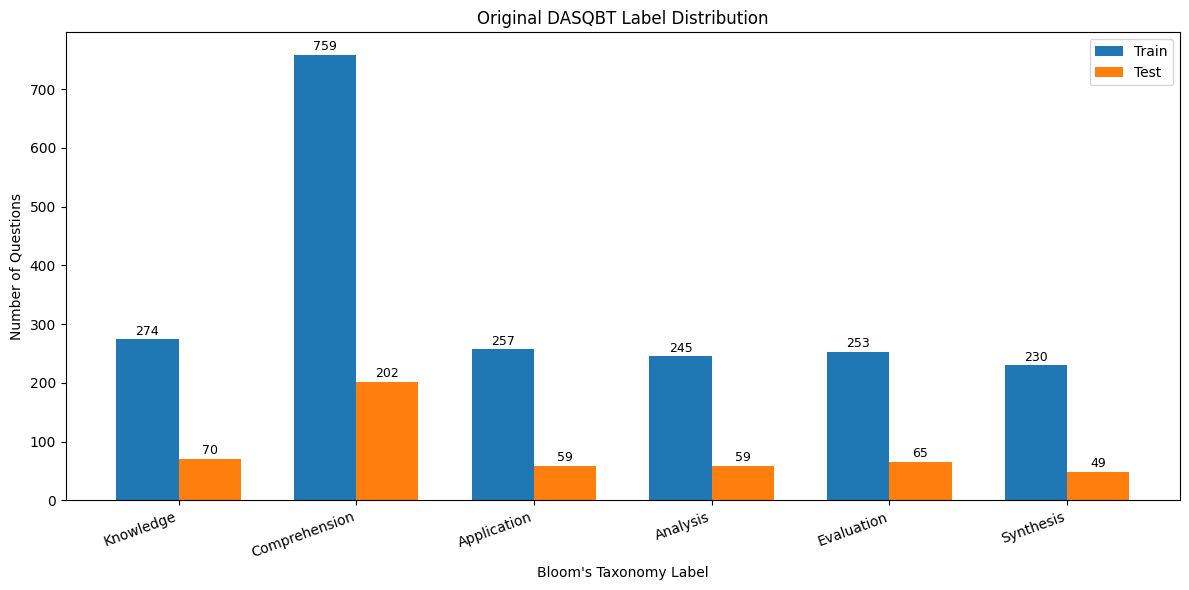

In [ ]:
label_order = ["Knowledge", "Comprehension", "Application", "Analysis", "Evaluation", "Synthesis"]

train_counts = train_df["BT LEVEL"].value_counts().reindex(label_order)
test_counts = test_df["BT LEVEL"].value_counts().reindex(label_order)

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(label_order))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, train_counts.values, width, label="Train")
bars2 = plt.bar(x + width/2, test_counts.values, width, label="Test")

plt.title("Original DASQBT Label Distribution")
plt.xlabel("Bloom's Taxonomy Label")
plt.ylabel("Number of Questions")
plt.xticks(x, label_order, rotation=20, ha="right")
plt.legend()

# Add count labels above bars
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Part 2 — Dataset Preparation and Audit

### The original DASQBT data is prepared for STUDI's four-class classification task before model development.

This stage restricts the dataset to the cognitive levels included in STUDI, maps the original Bloom's Taxonomy labels to the terminology used by the system, checks for potential data-quality issues, and prepares a validation subset while preserving the provided test partition for final evaluation.

## 2.1 Select STUDI's Four Cognitive Levels

### STUDI focuses on four cognitive levels: Remembering, Understanding, Applying, and Analyzing.

### The corresponding original DASQBT categories are Knowledge, Comprehension, Application, and Analysis. Evaluation and Synthesis are excluded because they are outside the defined scope of STUDI rather than because of data-quality concerns.

In [ ]:
# Original DASQBT labels corresponding to STUDI's four target levels
target_labels = [
    "Knowledge",
    "Comprehension",
    "Application",
    "Analysis"
]

# Apply the same predefined scope filter to both published partitions.
train_studi = train_df[
    train_df["BT LEVEL"].isin(target_labels)
].copy()

test_studi = test_df[
    test_df["BT LEVEL"].isin(target_labels)
].copy()

print("Original training rows:", len(train_df))
print("STUDI training rows:", len(train_studi))
print("Rows excluded from training:", len(train_df) - len(train_studi))

print()

print("Original test rows:", len(test_df))
print("STUDI test rows:", len(test_studi))
print("Rows excluded from test:", len(test_df) - len(test_studi))

Original training rows: 2018
STUDI training rows: 1535
Rows excluded from training: 483

Original test rows: 504
STUDI test rows: 390
Rows excluded from test: 114


In [ ]:
print("STUDI training label distribution:")
print(train_studi["BT LEVEL"].value_counts())

print("\nSTUDI test label distribution:")
print(test_studi["BT LEVEL"].value_counts())

STUDI training label distribution:
BT LEVEL
Comprehension    759
Knowledge        274
Application      257
Analysis         245
Name: count, dtype: int64

STUDI test label distribution:
BT LEVEL
Comprehension    202
Knowledge         70
Application       59
Analysis          59
Name: count, dtype: int64


In [ ]:
assert set(train_studi["BT LEVEL"].unique()) == set(target_labels)
assert set(test_studi["BT LEVEL"].unique()) == set(target_labels)

assert len(train_studi) == 1535
assert len(test_studi) == 390

print("Four-class scope verification passed.")

Four-class scope verification passed.


## 2.2 Map DASQBT Labels to STUDI Cognitive Levels

### The retained DASQBT labels are mapped to the terminology used by STUDI.

### DASQBT uses the labels Knowledge, Comprehension, Application, and Analysis. For consistency with STUDI's use of the Revised Bloom's Taxonomy terminology, these are mapped to Remembering, Understanding, Applying, and Analyzing respectively.

The original DASQBT label is preserved rather than overwritten so that the source annotation remains traceable.

In [ ]:
label_mapping = {
    "Knowledge": "Remembering",
    "Comprehension": "Understanding",
    "Application": "Applying",
    "Analysis": "Analyzing"
}

train_studi["STUDI LEVEL"] = train_studi["BT LEVEL"].map(label_mapping)
test_studi["STUDI LEVEL"] = test_studi["BT LEVEL"].map(label_mapping)

print("Training data preview:")
display(train_studi.head())

print("\nTest data preview:")
display(test_studi.head())

Training data preview:


,QUESTION,BT LEVEL,STUDI LEVEL
0,Independent Non-Executive Directors (INEDs) pl...,Comprehension,Understanding
1,Briefly discuss the advantage of C3 and C4 pat...,Comprehension,Understanding
2,"In a table form, differentiate between RefSeq ...",Analysis,Analyzing
3,The structural view of language has several co...,Knowledge,Remembering
4,Audio plays an important role in the developme...,Comprehension,Understanding



Test data preview:


,QUESTION,BT LEVEL,STUDI LEVEL
0,Explain the concept of price leadership observ...,Comprehension,Understanding
1,Explain the meaning of the law of diminishing ...,Comprehension,Understanding
2,Identify THREE (3) types of imperfectly compet...,Application,Applying
3,Explain types of price discriminations.,Comprehension,Understanding
4,Briefly explain the characteristics of monopol...,Comprehension,Understanding


In [ ]:
print("Missing mapped labels in training set:",
      train_studi["STUDI LEVEL"].isnull().sum())

print("Missing mapped labels in test set:",
      test_studi["STUDI LEVEL"].isnull().sum())

print("\nSTUDI training label distribution:")
print(train_studi["STUDI LEVEL"].value_counts())

print("\nSTUDI test label distribution:")
print(test_studi["STUDI LEVEL"].value_counts())

Missing mapped labels in training set: 0
Missing mapped labels in test set: 0

STUDI training label distribution:
STUDI LEVEL
Understanding    759
Remembering      274
Applying         257
Analyzing        245
Name: count, dtype: int64

STUDI test label distribution:
STUDI LEVEL
Understanding    202
Remembering       70
Applying          59
Analyzing         59
Name: count, dtype: int64


In [ ]:
expected_mapping = {
    "Knowledge": "Remembering",
    "Comprehension": "Understanding",
    "Application": "Applying",
    "Analysis": "Analyzing"
}

observed_mapping = (
    train_studi[["BT LEVEL", "STUDI LEVEL"]]
    .drop_duplicates()
    .set_index("BT LEVEL")["STUDI LEVEL"]
    .to_dict()
)

assert observed_mapping == expected_mapping
assert train_studi["STUDI LEVEL"].notna().all()
assert test_studi["STUDI LEVEL"].notna().all()

print("Label mapping verification passed.")

Label mapping verification passed.


## 2.3 Data Quality Audit

### The retained four-class dataset is checked for structural issues before creating the validation split.

###This audit examines blank or whitespace-only questions, repeated questions within each partition, overlap between the provided training and test partitions, and cases where identical question text may have conflicting cognitive-level labels.
### A lightly normalized copy of each question is created only for duplicate detection. The original question text is preserved and is not replaced during this audit.

In [ ]:
# Check for empty or whitespace-only questions
train_blank = train_studi["QUESTION"].astype(str).str.strip().eq("").sum()
test_blank = test_studi["QUESTION"].astype(str).str.strip().eq("").sum()

# Check for leading or trailing whitespace
train_outer_space = (
    train_studi["QUESTION"].astype(str)
    != train_studi["QUESTION"].astype(str).str.strip()
).sum()

test_outer_space = (
    test_studi["QUESTION"].astype(str)
    != test_studi["QUESTION"].astype(str).str.strip()
).sum()

print("Blank/whitespace-only questions")
print("Training:", train_blank)
print("Test:", test_blank)

print("\nQuestions with leading/trailing whitespace")
print("Training:", train_outer_space)
print("Test:", test_outer_space)

Blank/whitespace-only questions
Training: 0
Test: 0

Questions with leading/trailing whitespace
Training: 746
Test: 182


In [ ]:
def normalize_for_audit(text):
    return (
        str(text)
        .strip()
        .lower()
        .replace("\n", " ")
    )

train_studi["AUDIT_QUESTION"] = (
    train_studi["QUESTION"]
    .apply(normalize_for_audit)
    .str.replace(r"\s+", " ", regex=True)
)

test_studi["AUDIT_QUESTION"] = (
    test_studi["QUESTION"]
    .apply(normalize_for_audit)
    .str.replace(r"\s+", " ", regex=True)
)

print("Audit normalization created.")

Audit normalization created.


In [ ]:
train_duplicate_rows = train_studi.duplicated(
    subset="AUDIT_QUESTION",
    keep=False
)

test_duplicate_rows = test_studi.duplicated(
    subset="AUDIT_QUESTION",
    keep=False
)

print("Rows involved in duplicated questions")
print("Training:", train_duplicate_rows.sum())
print("Test:", test_duplicate_rows.sum())

print("\nUnique duplicated question texts")
print(
    "Training:",
    train_studi.loc[train_duplicate_rows, "AUDIT_QUESTION"].nunique()
)
print(
    "Test:",
    test_studi.loc[test_duplicate_rows, "AUDIT_QUESTION"].nunique()
)

Rows involved in duplicated questions
Training: 180
Test: 6

Unique duplicated question texts
Training: 87
Test: 3


In [ ]:
train_question_set = set(train_studi["AUDIT_QUESTION"])
test_question_set = set(test_studi["AUDIT_QUESTION"])

overlap_questions = train_question_set.intersection(test_question_set)

print("Unique questions appearing in BOTH train and test:")
print(len(overlap_questions))

Unique questions appearing in BOTH train and test:
34


In [ ]:
combined_audit = pd.concat(
    [
        train_studi.assign(SPLIT="Train"),
        test_studi.assign(SPLIT="Test")
    ],
    ignore_index=True
)

label_counts_per_question = (
    combined_audit
    .groupby("AUDIT_QUESTION")["STUDI LEVEL"]
    .nunique()
)

conflicting_questions = label_counts_per_question[
    label_counts_per_question > 1
].index

print("Identical questions with conflicting STUDI labels:")
print(len(conflicting_questions))

Identical questions with conflicting STUDI labels:
0


In [ ]:
if len(overlap_questions) > 0:
    print("Sample train-test overlaps:")

    overlap_df = combined_audit[
        combined_audit["AUDIT_QUESTION"].isin(overlap_questions)
    ][
        ["QUESTION", "BT LEVEL", "STUDI LEVEL", "SPLIT"]
    ].sort_values("QUESTION")

    display(overlap_df.head(20))
else:
    print("No train-test question overlap detected.")

Sample train-test overlaps:


,QUESTION,BT LEVEL,STUDI LEVEL,SPLIT
1251,Briefly describe THREE (3) types of busine...,Knowledge,Remembering,Train
1826,Briefly describe THREE (3) types of busine...,Knowledge,Remembering,Test
1858,Briefly discuss on the difference between ...,Comprehension,Understanding,Test
198,Briefly discuss on the difference between ...,Comprehension,Understanding,Train
1828,Briefly discuss any TWO (2) consequences for w...,Comprehension,Understanding,Test
710,Briefly discuss any TWO (2) consequences for w...,Comprehension,Understanding,Train
1725,Briefly explain the Auger process.,Comprehension,Understanding,Test
971,Briefly explain the Auger process.,Comprehension,Understanding,Train
897,Critically discuss how demographic characteris...,Analysis,Analyzing,Train
1907,Critically discuss how demographic characteris...,Analysis,Analyzing,Test


In [ ]:
if len(conflicting_questions) > 0:
    print("Sample conflicting-label questions:")

    conflict_df = combined_audit[
        combined_audit["AUDIT_QUESTION"].isin(conflicting_questions)
    ][
        ["QUESTION", "BT LEVEL", "STUDI LEVEL", "SPLIT"]
    ].sort_values("QUESTION")

    display(conflict_df.head(20))
else:
    print("No conflicting labels detected among identical questions.")

No conflicting labels detected among identical questions.


### The extent of train–test overlap is quantified before cleaning.

Because multiple rows may contain the same duplicated question, both the number of unique overlapping questions and the number of affected rows are measured. The class distribution of the affected test questions is also inspected before any records are removed.

In [ ]:
train_overlap_mask = train_studi["AUDIT_QUESTION"].isin(overlap_questions)
test_overlap_mask = test_studi["AUDIT_QUESTION"].isin(overlap_questions)

print("Unique overlapping question texts:", len(overlap_questions))

print("\nTraining rows involved in train-test overlap:")
print(train_overlap_mask.sum())

print("\nTest rows involved in train-test overlap:")
print(test_overlap_mask.sum())

print("\nPercentage of STUDI test rows affected:")
print(f"{test_overlap_mask.mean() * 100:.2f}%")

Unique overlapping question texts: 34

Training rows involved in train-test overlap:
38

Test rows involved in train-test overlap:
35

Percentage of STUDI test rows affected:
8.97%


In [ ]:
print("Overlapping test rows by STUDI level:")
print(
    test_studi.loc[test_overlap_mask, "STUDI LEVEL"]
    .value_counts()
)

print("\nTest distribution after excluding overlap:")
print(
    test_studi.loc[~test_overlap_mask, "STUDI LEVEL"]
    .value_counts()
)

Overlapping test rows by STUDI level:
STUDI LEVEL
Understanding    16
Remembering       7
Analyzing         7
Applying          5
Name: count, dtype: int64

Test distribution after excluding overlap:
STUDI LEVEL
Understanding    186
Remembering       63
Applying          54
Analyzing         52
Name: count, dtype: int64


## 2.4 Clean Exact Duplicates and Whitespace


### Exact duplicates and train–test overlap identified during the audit are removed before model development.

### Question text is first normalized for harmless whitespace differences while preserving the original text for traceability. Exact duplicate questions within each partition are then reduced to one instance because identical questions were found to have consistent cognitive-level labels.

### Finally, questions appearing in both the training and test partitions are removed from the test set so that final evaluation is performed only on questions unseen during training. The original DASQBT train/test assignment is otherwise preserved.

In [ ]:
train_clean = train_studi.copy()
test_clean = test_studi.copy()

# Preserve the source text before applying harmless whitespace normalization.
train_clean["ORIGINAL QUESTION"] = train_clean["QUESTION"]
test_clean["ORIGINAL QUESTION"] = test_clean["QUESTION"]

# Normalize leading, trailing, and repeated whitespace.
train_clean["QUESTION"] = (
    train_clean["QUESTION"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

test_clean["QUESTION"] = (
    test_clean["QUESTION"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Whitespace normalization completed.")

Whitespace normalization completed.


In [ ]:
train_clean["AUDIT_QUESTION"] = (
    train_clean["QUESTION"]
    .str.lower()
)

test_clean["AUDIT_QUESTION"] = (
    test_clean["QUESTION"]
    .str.lower()
)

In [ ]:
train_before_dedup = len(train_clean)
test_before_dedup = len(test_clean)

train_clean = (
    train_clean
    .drop_duplicates(subset="AUDIT_QUESTION", keep="first")
    .copy()
)

test_clean = (
    test_clean
    .drop_duplicates(subset="AUDIT_QUESTION", keep="first")
    .copy()
)

print("Training rows before deduplication:", train_before_dedup)
print("Training rows after deduplication:", len(train_clean))
print("Training duplicate rows removed:",
      train_before_dedup - len(train_clean))

print()

print("Test rows before deduplication:", test_before_dedup)
print("Test rows after deduplication:", len(test_clean))
print("Test duplicate rows removed:",
      test_before_dedup - len(test_clean))

Training rows before deduplication: 1535
Training rows after deduplication: 1442
Training duplicate rows removed: 93

Test rows before deduplication: 390
Test rows after deduplication: 387
Test duplicate rows removed: 3


In [ ]:
clean_train_questions = set(train_clean["AUDIT_QUESTION"])

test_overlap_after_dedup = test_clean[
    test_clean["AUDIT_QUESTION"].isin(clean_train_questions)
]

print("Unique test questions still present in training:",
      test_overlap_after_dedup["AUDIT_QUESTION"].nunique())

print("Test rows to remove due to train-test overlap:",
      len(test_overlap_after_dedup))

Unique test questions still present in training: 34
Test rows to remove due to train-test overlap: 34


In [ ]:
test_before_overlap_removal = len(test_clean)

test_clean = test_clean[
    ~test_clean["AUDIT_QUESTION"].isin(clean_train_questions)
].copy()

print("Test rows before overlap removal:",
      test_before_overlap_removal)

print("Test rows after overlap removal:",
      len(test_clean))

print("Overlapping test rows removed:",
      test_before_overlap_removal - len(test_clean))

Test rows before overlap removal: 387
Test rows after overlap removal: 353
Overlapping test rows removed: 34


In [ ]:
# No blank questions
assert train_clean["QUESTION"].str.strip().ne("").all()
assert test_clean["QUESTION"].str.strip().ne("").all()

# No exact duplicates inside either partition
assert not train_clean["AUDIT_QUESTION"].duplicated().any()
assert not test_clean["AUDIT_QUESTION"].duplicated().any()

# No exact question overlap between training and test
remaining_overlap = (
    set(train_clean["AUDIT_QUESTION"])
    .intersection(set(test_clean["AUDIT_QUESTION"]))
)

assert len(remaining_overlap) == 0

print("Dataset cleaning verification passed.")
print("No blank questions.")
print("No within-partition exact duplicates.")
print("No train-test exact overlap.")

Dataset cleaning verification passed.
No blank questions.
No within-partition exact duplicates.
No train-test exact overlap.


In [ ]:
print("Final cleaned training size:", len(train_clean))
print("Final cleaned test size:", len(test_clean))

print("\nCleaned training distribution:")
print(train_clean["STUDI LEVEL"].value_counts())

print("\nCleaned test distribution:")
print(test_clean["STUDI LEVEL"].value_counts())

Final cleaned training size: 1442
Final cleaned test size: 353

Cleaned training distribution:
STUDI LEVEL
Understanding    730
Remembering      258
Applying         231
Analyzing        223
Name: count, dtype: int64

Cleaned test distribution:
STUDI LEVEL
Understanding    185
Remembering       63
Applying          54
Analyzing         51
Name: count, dtype: int64


## 2.5 Near-Duplicate Leakage Audit

### Exact duplicates have been removed, but highly similar question pairs may still occur across the cleaned training and test partitions.

### Character-level TF-IDF similarity is used as a diagnostic tool to identify test questions that closely resemble training questions despite not being exact textual matches.

### Similarity scores are used only to flag candidates for inspection and are not treated as an automatic deletion rule.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Reset indices after cleaning for easier pair inspection.
train_clean = train_clean.reset_index(drop=True)
test_clean = test_clean.reset_index(drop=True)

near_dup_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    lowercase=True
)

# Fit jointly for audit purposes only.
audit_questions = pd.concat(
    [train_clean["QUESTION"], test_clean["QUESTION"]],
    ignore_index=True
)

near_dup_vectorizer.fit(audit_questions)

train_audit_matrix = near_dup_vectorizer.transform(
    train_clean["QUESTION"]
)

test_audit_matrix = near_dup_vectorizer.transform(
    test_clean["QUESTION"]
)

similarity_matrix = cosine_similarity(
    test_audit_matrix,
    train_audit_matrix
)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (353, 1442)


In [ ]:
best_train_indices = similarity_matrix.argmax(axis=1)
best_similarity_scores = similarity_matrix.max(axis=1)

near_duplicate_audit = pd.DataFrame({
    "TEST QUESTION": test_clean["QUESTION"],
    "TEST LEVEL": test_clean["STUDI LEVEL"],
    "BEST TRAIN MATCH": train_clean.iloc[best_train_indices]["QUESTION"].values,
    "TRAIN LEVEL": train_clean.iloc[best_train_indices]["STUDI LEVEL"].values,
    "SIMILARITY": best_similarity_scores
})

near_duplicate_audit["SAME LABEL"] = (
    near_duplicate_audit["TEST LEVEL"]
    == near_duplicate_audit["TRAIN LEVEL"]
)

print("Near-duplicate audit table created.")

Near-duplicate audit table created.


In [ ]:
best_train_indices = similarity_matrix.argmax(axis=1)
best_similarity_scores = similarity_matrix.max(axis=1)

near_duplicate_audit = pd.DataFrame({
    "TEST QUESTION": test_clean["QUESTION"],
    "TEST LEVEL": test_clean["STUDI LEVEL"],
    "BEST TRAIN MATCH": train_clean.iloc[best_train_indices]["QUESTION"].values,
    "TRAIN LEVEL": train_clean.iloc[best_train_indices]["STUDI LEVEL"].values,
    "SIMILARITY": best_similarity_scores
})

near_duplicate_audit["SAME LABEL"] = (
    near_duplicate_audit["TEST LEVEL"]
    == near_duplicate_audit["TRAIN LEVEL"]
)

print("Near-duplicate audit table created.")

Near-duplicate audit table created.


In [ ]:
thresholds = [0.80, 0.85, 0.90, 0.95]

print("High-similarity train-test candidates:\n")

for threshold in thresholds:
    count = (
        near_duplicate_audit["SIMILARITY"] >= threshold
    ).sum()

    percentage = count / len(near_duplicate_audit) * 100

    print(
        f"Similarity ≥ {threshold:.2f}: "
        f"{count} questions ({percentage:.2f}%)"
    )

High-similarity train-test candidates:

Similarity ≥ 0.80: 11 questions (3.12%)
Similarity ≥ 0.85: 9 questions (2.55%)
Similarity ≥ 0.90: 8 questions (2.27%)
Similarity ≥ 0.95: 4 questions (1.13%)


### Distribution of Maximum Train–Test Similarity

### The distribution below shows the highest textual similarity between each cleaned test question and any question in the cleaned training set.

### Questions near the upper end of the similarity range are inspected as possible near-duplicate leakage candidates.

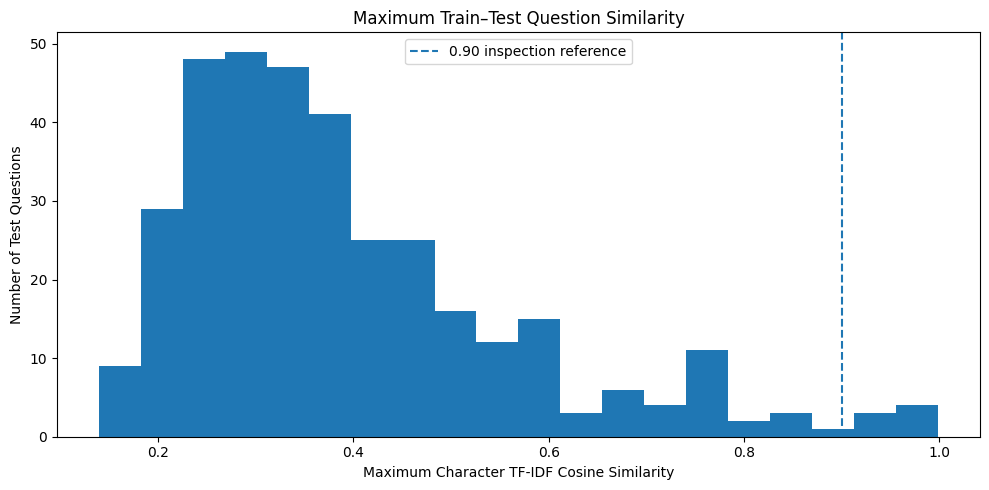

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    near_duplicate_audit["SIMILARITY"],
    bins=20
)

plt.axvline(
    0.90,
    linestyle="--",
    label="0.90 inspection reference"
)

plt.title("Maximum Train–Test Question Similarity")
plt.xlabel("Maximum Character TF-IDF Cosine Similarity")
plt.ylabel("Number of Test Questions")
plt.legend()

plt.tight_layout()
plt.show()

### Near-Duplicate Audit Interpretation

### The similarity audit identified a small number of highly similar train–test question pairs. However, manual inspection showed that high textual similarity did not consistently indicate duplicate assessment items. Some pairs shared nearly identical wording while referring to different concepts, quantities, or requested operations.

### For this reason, similarity scores were not used as an automatic exclusion criterion. The cleaned test partition was retained after removal of exact normalized duplicates and exact train–test overlap only.

In [ ]:
top_near_duplicates = (
    near_duplicate_audit
    .sort_values("SIMILARITY", ascending=False)
    .head(20)
)

display(
    top_near_duplicates[
        [
            "TEST QUESTION",
            "BEST TRAIN MATCH",
            "SIMILARITY",
            "TEST LEVEL",
            "TRAIN LEVEL",
            "SAME LABEL"
        ]
    ]
)

,TEST QUESTION,BEST TRAIN MATCH,SIMILARITY,TEST LEVEL,TRAIN LEVEL,SAME LABEL
199,Briefly explain how aggregation processes coul...,Briefly explain how the aggregation processes ...,0.998664,Understanding,Understanding,True
197,Briefly explain the differences between a Lang...,Briefly explain the differences between and La...,0.997486,Understanding,Understanding,True
189,Sketch the Type I isotherm and provide a brief...,Sketch the Type Il isotherm and provide a brie...,0.986832,Applying,Applying,True
293,How can you describe _____________?,How would you express ________________?,0.976187,Understanding,Understanding,True
83,Draw a technology enhanced language learning c...,Draw a technology enhanced language learning c...,0.949829,Understanding,Understanding,True
193,Give THREE disadvantages of X-Ray Photoelectro...,Give TWO advantages of X-Ray Photoelectron Spe...,0.941794,Understanding,Understanding,True
352,List any SEVEN (7) suggestions for good presen...,Presenting the business plan is very crucial t...,0.931321,Remembering,Remembering,True
187,Briefly explain the main feature of the struct...,Briefly explain and draw the structure of dilu...,0.909926,Understanding,Understanding,True
351,"Compare how the Net Present Value (NPV), IRR m...",Compare how the internal rate of return (IRR) ...,0.855557,Analyzing,Analyzing,True
26,"""Trading strategies used by investors of futur...","""Investment strategies used by the investors o...",0.848805,Analyzing,Analyzing,True


In [ ]:
high_similarity_candidates = (
    near_duplicate_audit[
        near_duplicate_audit["SIMILARITY"] >= 0.90
    ]
    .sort_values("SIMILARITY", ascending=False)
)

print(
    "Candidates at or above 0.90:",
    len(high_similarity_candidates)
)

display(
    high_similarity_candidates[
        [
            "TEST QUESTION",
            "BEST TRAIN MATCH",
            "SIMILARITY",
            "TEST LEVEL",
            "TRAIN LEVEL",
            "SAME LABEL"
        ]
    ].head(20)
)

Candidates at or above 0.90: 8


,TEST QUESTION,BEST TRAIN MATCH,SIMILARITY,TEST LEVEL,TRAIN LEVEL,SAME LABEL
199,Briefly explain how aggregation processes coul...,Briefly explain how the aggregation processes ...,0.998664,Understanding,Understanding,True
197,Briefly explain the differences between a Lang...,Briefly explain the differences between and La...,0.997486,Understanding,Understanding,True
189,Sketch the Type I isotherm and provide a brief...,Sketch the Type Il isotherm and provide a brie...,0.986832,Applying,Applying,True
293,How can you describe _____________?,How would you express ________________?,0.976187,Understanding,Understanding,True
83,Draw a technology enhanced language learning c...,Draw a technology enhanced language learning c...,0.949829,Understanding,Understanding,True
193,Give THREE disadvantages of X-Ray Photoelectro...,Give TWO advantages of X-Ray Photoelectron Spe...,0.941794,Understanding,Understanding,True
352,List any SEVEN (7) suggestions for good presen...,Presenting the business plan is very crucial t...,0.931321,Remembering,Remembering,True
187,Briefly explain the main feature of the struct...,Briefly explain and draw the structure of dilu...,0.909926,Understanding,Understanding,True


## 2.6 Create the Training and Validation Split

### The cleaned DASQBT training partition is divided into training and validation subsets using stratified sampling.

### The validation subset is used during model development for model selection, learning-curve analysis, hyperparameter decisions, and other experimental comparisons.

### Stratification preserves approximately the same cognitive-level proportions across the training and validation subsets. The cleaned test partition remains separate and is reserved for final evaluation after model-development decisions have been completed.

In [ ]:
X = train_clean["QUESTION"]
y = train_clean["STUDI LEVEL"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training subset size:", len(X_train))
print("Validation subset size:", len(X_val))
print("Reserved test size:", len(test_clean))

Training subset size: 1153
Validation subset size: 289
Reserved test size: 353


In [ ]:
train_split_counts = y_train.value_counts()
val_split_counts = y_val.value_counts()

print("Training subset distribution:")
print(train_split_counts)

print("\nValidation subset distribution:")
print(val_split_counts)

print("\nReserved test distribution:")
print(test_clean["STUDI LEVEL"].value_counts())

Training subset distribution:
STUDI LEVEL
Understanding    584
Remembering      206
Applying         185
Analyzing        178
Name: count, dtype: int64

Validation subset distribution:
STUDI LEVEL
Understanding    146
Remembering       52
Applying          46
Analyzing         45
Name: count, dtype: int64

Reserved test distribution:
STUDI LEVEL
Understanding    185
Remembering       63
Applying          54
Analyzing         51
Name: count, dtype: int64


In [ ]:
assert len(X_train) + len(X_val) == len(train_clean)

assert set(y_train.unique()) == set(label_mapping.values())
assert set(y_val.unique()) == set(label_mapping.values())

assert X_train.index.intersection(X_val.index).empty

print("Train-validation split verification passed.")

Train-validation split verification passed.


### Cognitive-Level Distribution Across Data Partitions

### The proportional class distributions of the training, validation, and reserved test partitions are compared to verify that stratified sampling preserved the class balance of the development data.

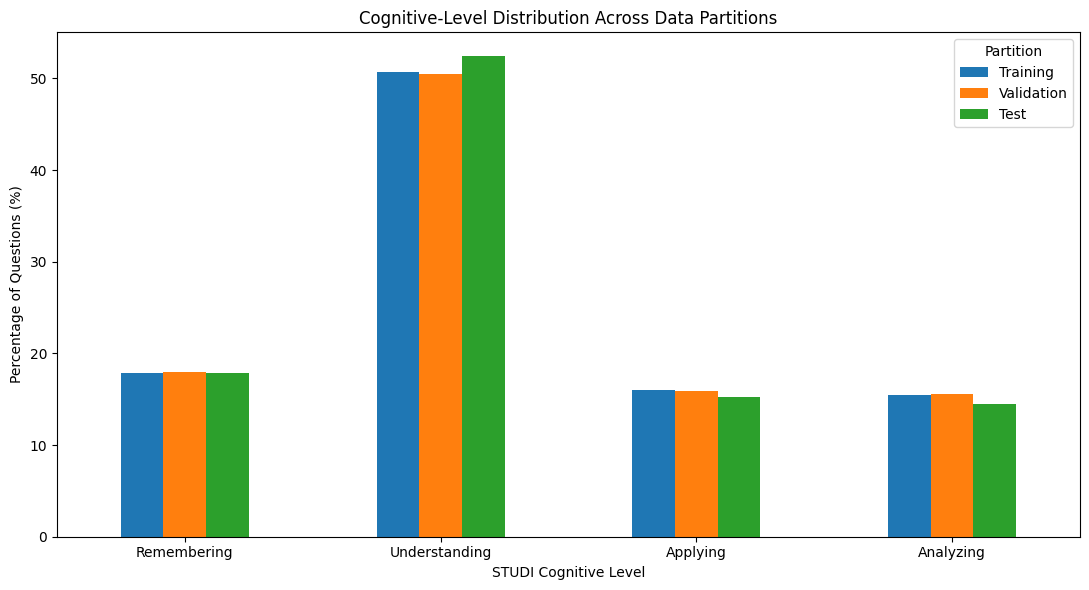

In [ ]:
train_pct = (
    y_train.value_counts(normalize=True)
    .reindex(label_mapping.values())
    * 100
)

val_pct = (
    y_val.value_counts(normalize=True)
    .reindex(label_mapping.values())
    * 100
)

test_pct = (
    test_clean["STUDI LEVEL"]
    .value_counts(normalize=True)
    .reindex(label_mapping.values())
    * 100
)

distribution_df = pd.DataFrame({
    "Training": train_pct,
    "Validation": val_pct,
    "Test": test_pct
})

distribution_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Cognitive-Level Distribution Across Data Partitions")
plt.xlabel("STUDI Cognitive Level")
plt.ylabel("Percentage of Questions (%)")
plt.xticks(rotation=0)
plt.legend(title="Partition")

plt.tight_layout()
plt.show()

## 2.7 Save the Prepared Dataset Checkpoint

In [ ]:
train_checkpoint = pd.DataFrame({
    "QUESTION": X_train,
    "STUDI LEVEL": y_train
}).reset_index(drop=True)

val_checkpoint = pd.DataFrame({
    "QUESTION": X_val,
    "STUDI LEVEL": y_val
}).reset_index(drop=True)

test_checkpoint = test_clean[
    ["QUESTION", "STUDI LEVEL"]
].reset_index(drop=True)

train_checkpoint.to_csv("studi_train.csv", index=False)
val_checkpoint.to_csv("studi_validation.csv", index=False)
test_checkpoint.to_csv("studi_test.csv", index=False)

print("Checkpoint files created.")
print("Training:", train_checkpoint.shape)
print("Validation:", val_checkpoint.shape)
print("Test:", test_checkpoint.shape)

Checkpoint files created.
Training: (1153, 2)
Validation: (289, 2)
Test: (353, 2)


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
checkpoint_dir = "/content/drive/MyDrive/STUDI_Checkpoint"

import os
os.makedirs(checkpoint_dir, exist_ok=True)

train_checkpoint.to_csv(
    f"{checkpoint_dir}/studi_train.csv",
    index=False
)

val_checkpoint.to_csv(
    f"{checkpoint_dir}/studi_validation.csv",
    index=False
)

test_checkpoint.to_csv(
    f"{checkpoint_dir}/studi_test.csv",
    index=False
)

print("Part 2 checkpoint saved to Google Drive.")

Part 2 checkpoint saved to Google Drive.


# Part 3 — TF-IDF + Linear SVM Baseline

### The prepared dataset checkpoint is restored before model development begins.

###The finalized training, validation, and reserved test partitions created in Part 2 are reloaded from Google Drive. This allows model development to continue without repeating the dataset preparation and audit procedures.

###The reserved test partition remains excluded from model development and will only be used during final evaluation.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import random
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

checkpoint_dir = "/content/drive/MyDrive/STUDI_Checkpoint"

train_checkpoint = pd.read_csv(
    f"{checkpoint_dir}/studi_train.csv"
)

val_checkpoint = pd.read_csv(
    f"{checkpoint_dir}/studi_validation.csv"
)

test_checkpoint = pd.read_csv(
    f"{checkpoint_dir}/studi_test.csv"
)

X_train = train_checkpoint["QUESTION"]
y_train = train_checkpoint["STUDI LEVEL"]

X_val = val_checkpoint["QUESTION"]
y_val = val_checkpoint["STUDI LEVEL"]

test_clean = test_checkpoint.copy()

print("Checkpoint restored.")
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Reserved test:", len(test_clean))

Checkpoint restored.
Training: 1153
Validation: 289
Reserved test: 353


In [ ]:
expected_levels = {
    "Remembering",
    "Understanding",
    "Applying",
    "Analyzing"
}

assert len(X_train) == 1153
assert len(X_val) == 289
assert len(test_clean) == 353

assert set(y_train.unique()) == expected_levels
assert set(y_val.unique()) == expected_levels
assert set(test_clean["STUDI LEVEL"].unique()) == expected_levels

print("Checkpoint verification passed.")

Checkpoint verification passed.


## 3.1 Build the Initial TF-IDF + Linear SVM Pipeline

### TF-IDF with a Linear Support Vector Machine is used as the classical machine-learning baseline for STUDI's cognitive-level classification task.

###TF-IDF converts each educational question into a weighted numerical representation based on its textual features, while Linear SVM learns decision boundaries among the four cognitive levels.

###The initial configuration is intentionally kept simple so that later modifications can be evaluated against a clear baseline using the validation subset.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
svm_baseline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer()
    ),
    (
        "svm",
        LinearSVC(
            random_state=SEED,
            max_iter=5000
        )
    )
])

print(svm_baseline)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('svm', LinearSVC(max_iter=5000, random_state=42))])


In [ ]:
svm_baseline.fit(X_train, y_train)

print("TF-IDF + Linear SVM baseline training completed.")

TF-IDF + Linear SVM baseline training completed.


In [ ]:
y_val_pred_svm = svm_baseline.predict(X_val)

print("Validation predictions generated:", len(y_val_pred_svm))

Validation predictions generated: 289


In [ ]:
svm_baseline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('svm', LinearSVC(max_iter=5000, random_state=42))])

## 3.2 Evaluate the Initial SVM on the Validation Set

### The initial TF-IDF + Linear SVM model is evaluated using the validation subset.

Performance is measured using accuracy, macro-averaged precision, recall, and F1-score, together with weighted F1 and per-class results.

Macro F1 is emphasized because it gives equal importance to all four cognitive levels despite the class imbalance present in the dataset.

In [ ]:
svm_accuracy = accuracy_score(
    y_val,
    y_val_pred_svm
)

svm_macro_precision = precision_score(
    y_val,
    y_val_pred_svm,
    average="macro",
    zero_division=0
)

svm_macro_recall = recall_score(
    y_val,
    y_val_pred_svm,
    average="macro",
    zero_division=0
)

svm_macro_f1 = f1_score(
    y_val,
    y_val_pred_svm,
    average="macro",
    zero_division=0
)

svm_weighted_f1 = f1_score(
    y_val,
    y_val_pred_svm,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:        {svm_accuracy:.4f}")
print(f"Macro Precision: {svm_macro_precision:.4f}")
print(f"Macro Recall:    {svm_macro_recall:.4f}")
print(f"Macro F1:        {svm_macro_f1:.4f}")
print(f"Weighted F1:     {svm_weighted_f1:.4f}")

Accuracy:        0.7647
Macro Precision: 0.7774
Macro Recall:    0.6937
Macro F1:        0.7260
Weighted F1:     0.7583


In [ ]:
class_order = [
    "Remembering",
    "Understanding",
    "Applying",
    "Analyzing"
]

print(
    classification_report(
        y_val,
        y_val_pred_svm,
        labels=class_order,
        digits=4,
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Remembering     0.7750    0.5962    0.6739        52
Understanding     0.7543    0.9041    0.8224       146
     Applying     0.7317    0.6522    0.6897        46
    Analyzing     0.8485    0.6222    0.7179        45

     accuracy                         0.7647       289
    macro avg     0.7774    0.6937    0.7260       289
 weighted avg     0.7691    0.7647    0.7583       289



In [ ]:
validation_distribution = pd.DataFrame({
    "Actual": y_val.value_counts().reindex(class_order),
    "Predicted": pd.Series(y_val_pred_svm)
        .value_counts()
        .reindex(class_order, fill_value=0)
})

display(validation_distribution)

,Actual,Predicted
Remembering,52,40
Understanding,146,175
Applying,46,41
Analyzing,45,33


### Validation Confusion Matrix

The normalized confusion matrix shows how frequently questions from each actual cognitive level are assigned to each predicted level.

Normalization by the true class allows classification behavior to be compared across cognitive levels despite differences in class size.


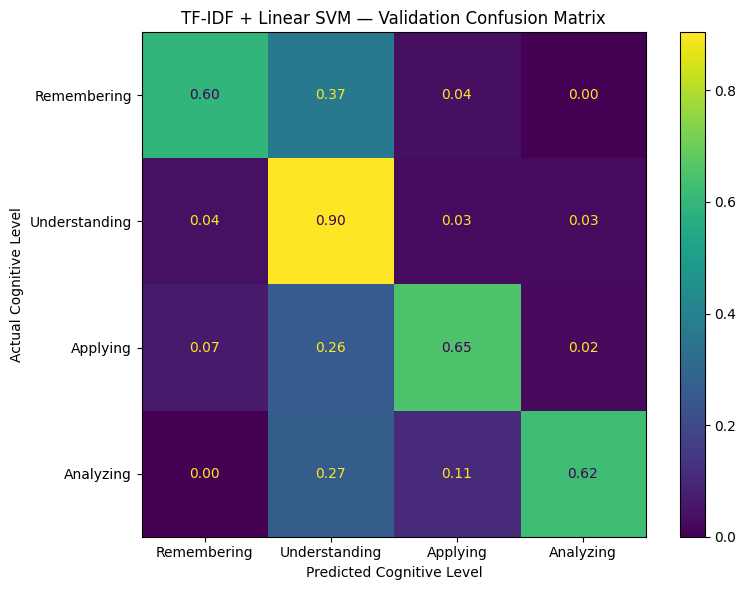

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_svm,
    labels=class_order,
    normalize="true",
    values_format=".2f",
    ax=ax
)

ax.set_title("TF-IDF + Linear SVM — Validation Confusion Matrix")
ax.set_xlabel("Predicted Cognitive Level")
ax.set_ylabel("Actual Cognitive Level")

plt.tight_layout()
plt.show()

### Initial Baseline Interpretation

The initial TF-IDF + Linear SVM achieved a validation accuracy of 76.47% and a Macro F1-score of 72.60%.

Performance was strongest for Understanding, which obtained a recall of 90.41%. In contrast, Remembering, Applying, and Analyzing obtained substantially lower recall values. The model also predicted Understanding more frequently than it occurred in the validation set while underpredicting the other three cognitive levels.

This pattern suggests that the class imbalance in the training data may influence the classifier toward the majority Understanding category. A class-weighted SVM is therefore evaluated as a controlled follow-up experiment.

## 3.3 Evaluate a Class-Weighted Linear SVM

### A class-weighted Linear SVM is evaluated to determine whether greater emphasis on minority cognitive levels improves balanced classification performance.

The TF-IDF representation and other model settings are kept unchanged from the initial baseline. Only class weighting is introduced so that its effect can be evaluated independently using the same validation subset.

In [ ]:
svm_balanced = Pipeline([
    (
        "tfidf",
        TfidfVectorizer()
    ),
    (
        "svm",
        LinearSVC(
            class_weight="balanced",
            random_state=SEED,
            max_iter=5000
        )
    )
])

svm_balanced.fit(X_train, y_train)

y_val_pred_balanced = svm_balanced.predict(X_val)

print("Class-weighted SVM training and validation prediction completed.")

Class-weighted SVM training and validation prediction completed.


In [ ]:
balanced_accuracy = accuracy_score(
    y_val,
    y_val_pred_balanced
)

balanced_macro_precision = precision_score(
    y_val,
    y_val_pred_balanced,
    average="macro",
    zero_division=0
)

balanced_macro_recall = recall_score(
    y_val,
    y_val_pred_balanced,
    average="macro",
    zero_division=0
)

balanced_macro_f1 = f1_score(
    y_val,
    y_val_pred_balanced,
    average="macro",
    zero_division=0
)

balanced_weighted_f1 = f1_score(
    y_val,
    y_val_pred_balanced,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:        {balanced_accuracy:.4f}")
print(f"Macro Precision: {balanced_macro_precision:.4f}")
print(f"Macro Recall:    {balanced_macro_recall:.4f}")
print(f"Macro F1:        {balanced_macro_f1:.4f}")
print(f"Weighted F1:     {balanced_weighted_f1:.4f}")

Accuracy:        0.7820
Macro Precision: 0.7769
Macro Recall:    0.7352
Macro F1:        0.7535
Weighted F1:     0.7789


In [ ]:
print(
    classification_report(
        y_val,
        y_val_pred_balanced,
        labels=class_order,
        digits=4,
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Remembering     0.7500    0.6346    0.6875        52
Understanding     0.7901    0.8767    0.8312       146
     Applying     0.7381    0.6739    0.7045        46
    Analyzing     0.8293    0.7556    0.7907        45

     accuracy                         0.7820       289
    macro avg     0.7769    0.7352    0.7535       289
 weighted avg     0.7807    0.7820    0.7789       289



In [ ]:
balanced_distribution = pd.DataFrame({
    "Actual": y_val.value_counts().reindex(class_order),
    "Predicted": pd.Series(y_val_pred_balanced)
        .value_counts()
        .reindex(class_order, fill_value=0)
})

display(balanced_distribution)

,Actual,Predicted
Remembering,52,44
Understanding,146,162
Applying,46,42
Analyzing,45,41


### Class-Weighted SVM Validation Confusion Matrix

The normalized confusion matrix is used to examine whether class weighting reduces the tendency of the baseline model to assign minority-class questions to the majority Understanding category.

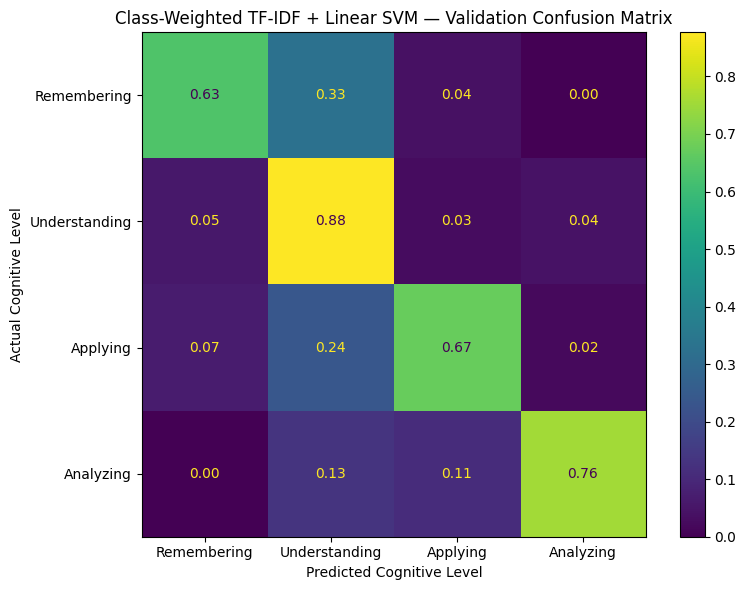

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_balanced,
    labels=class_order,
    normalize="true",
    values_format=".2f",
    ax=ax
)

ax.set_title("Class-Weighted TF-IDF + Linear SVM — Validation Confusion Matrix")
ax.set_xlabel("Predicted Cognitive Level")
ax.set_ylabel("Actual Cognitive Level")

plt.tight_layout()
plt.show()

In [ ]:
svm_comparison = pd.DataFrame({
    "Initial SVM": [
        svm_accuracy,
        svm_macro_precision,
        svm_macro_recall,
        svm_macro_f1,
        svm_weighted_f1
    ],
    "Class-Weighted SVM": [
        balanced_accuracy,
        balanced_macro_precision,
        balanced_macro_recall,
        balanced_macro_f1,
        balanced_weighted_f1
    ]
}, index=[
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
])

display(svm_comparison.round(4))

,Initial SVM,Class-Weighted SVM
Accuracy,0.7647,0.7820
Macro Precision,0.7774,0.7769
Macro Recall,0.6937,0.7352
Macro F1,0.7260,0.7535
Weighted F1,0.7583,0.7789


## 3.4 Compare the SVM Configurations

### The initial and class-weighted SVM configurations are compared using the same validation subset.

Because Macro F1 is the primary metric for the imbalanced four-class classification task, model selection emphasizes balanced performance across cognitive levels rather than accuracy alone.

The class-weighted configuration improves Macro F1, Macro Recall, accuracy, and Weighted F1 while maintaining nearly identical Macro Precision.

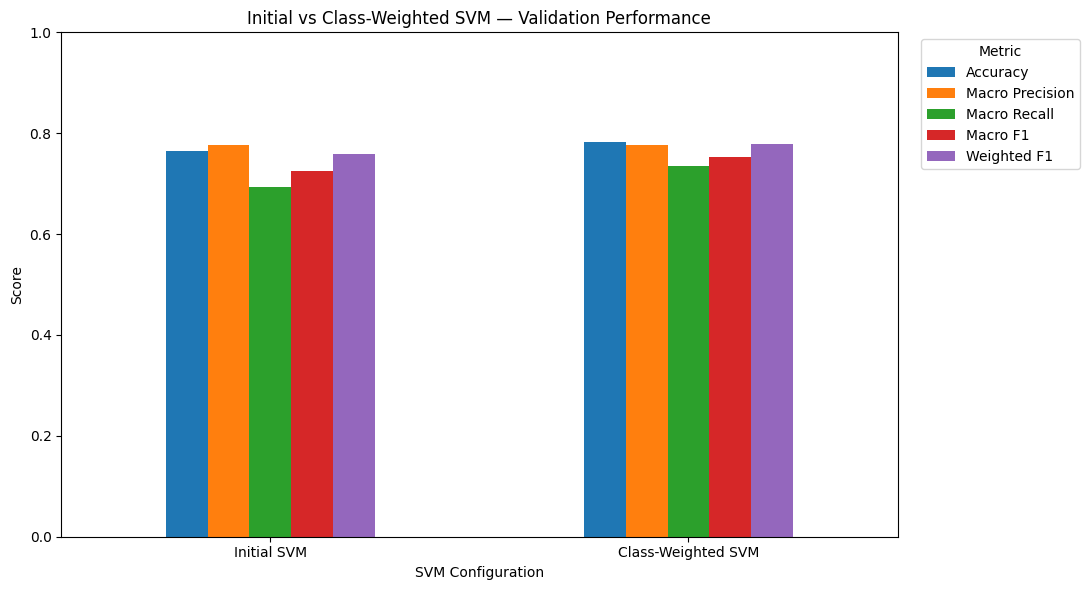

In [ ]:
comparison_plot = svm_comparison.T[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Initial vs Class-Weighted SVM — Validation Performance")
plt.xlabel("SVM Configuration")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### SVM Configuration Selection

The class-weighted TF-IDF + Linear SVM is retained for subsequent SVM experiments because it achieved the higher validation Macro F1-score (0.7535 compared with 0.7260) and substantially improved minority-class recall.

The initial unweighted model is retained as the baseline reference, while the class-weighted model represents the selected SVM configuration.

## 3.5 SVM Learning Curve

### A learning-curve experiment is conducted to examine how the selected class-weighted SVM responds to increasing amounts of training data.

Fresh models are trained using approximately 25%, 50%, 75%, and 100% of the available training subset while the same validation set is used for evaluation at every point.

The training subsets are stratified and nested so that class proportions are preserved and larger subsets extend the smaller subsets. The reserved test partition is not used in this experiment.

Training and validation Macro F1-scores are compared to determine whether additional training data continues to provide substantial performance gains or whether performance begins to plateau.

In [ ]:
train_learning_df = pd.DataFrame({
    "QUESTION": X_train.reset_index(drop=True),
    "STUDI LEVEL": y_train.reset_index(drop=True)
})

fractions = [0.25, 0.50, 0.75, 1.00]

# Create one reproducible shuffled ordering within each class.
rng = np.random.RandomState(SEED)

class_index_order = {}

for label in class_order:
    indices = train_learning_df.index[
        train_learning_df["STUDI LEVEL"] == label
    ].to_numpy().copy()

    rng.shuffle(indices)
    class_index_order[label] = indices

print("Nested stratified sampling structure prepared.")

Nested stratified sampling structure prepared.


In [ ]:
learning_curve_results = []
learning_subset_counts = []

for fraction in fractions:
    subset_indices = []

    for label in class_order:
        label_indices = class_index_order[label]

        if fraction == 1.00:
            n_samples = len(label_indices)
        else:
            n_samples = max(
                1,
                int(np.ceil(len(label_indices) * fraction))
            )

        subset_indices.extend(
            label_indices[:n_samples]
        )

    subset_df = (
        train_learning_df
        .loc[subset_indices]
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )

    X_subset = subset_df["QUESTION"]
    y_subset = subset_df["STUDI LEVEL"]

    # Each learning-curve point starts with a fresh model.
    curve_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer()
        ),
        (
            "svm",
            LinearSVC(
                class_weight="balanced",
                random_state=SEED,
                max_iter=5000
            )
        )
    ])

    curve_model.fit(X_subset, y_subset)

    train_pred = curve_model.predict(X_subset)
    val_pred = curve_model.predict(X_val)

    training_macro_f1 = f1_score(
        y_subset,
        train_pred,
        average="macro",
        zero_division=0
    )

    validation_macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    validation_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    learning_curve_results.append({
        "Training Fraction": f"{int(fraction * 100)}%",
        "Training Examples": len(X_subset),
        "Training Macro F1": training_macro_f1,
        "Validation Macro F1": validation_macro_f1,
        "Validation Accuracy": validation_accuracy
    })

    class_counts = (
        y_subset
        .value_counts()
        .reindex(class_order)
    )

    learning_subset_counts.append({
        "Training Fraction": f"{int(fraction * 100)}%",
        **class_counts.to_dict()
    })

print("SVM learning-curve experiment completed.")

SVM learning-curve experiment completed.


In [ ]:
learning_subset_counts_df = pd.DataFrame(
    learning_subset_counts
).set_index("Training Fraction")

display(learning_subset_counts_df)

,Remembering,Understanding,Applying,Analyzing
Training Fraction,,,,
25%,52,146,47,45
50%,103,292,93,89
75%,155,438,139,134
100%,206,584,185,178


In [ ]:
learning_curve_df = pd.DataFrame(
    learning_curve_results
)

display(
    learning_curve_df.round(4)
)

,Training Fraction,Training Examples,Training Macro F1,Validation Macro F1,Validation Accuracy
0,25%,290,1.0,0.6294,0.6920
1,50%,577,1.0,0.7294,0.7647
2,75%,866,1.0,0.7326,0.7716
3,100%,1153,1.0,0.7535,0.7820


### SVM Learning Curve

The learning curve compares training and validation Macro F1 as progressively larger portions of the available training data are used.

The validation trajectory indicates whether additional training examples continue to improve generalization, while the gap between training and validation performance provides additional evidence about potential overfitting.

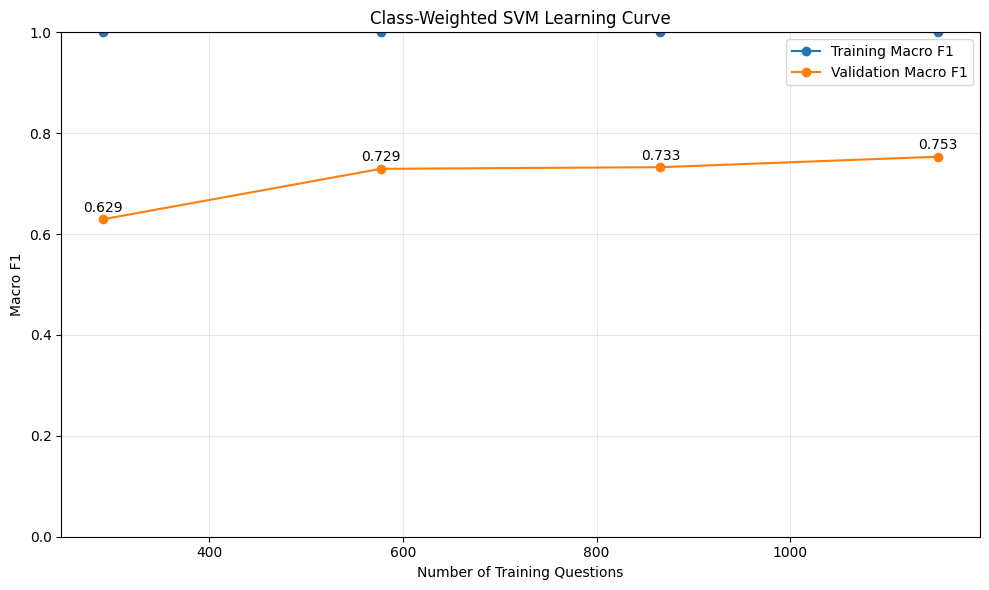

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    learning_curve_df["Training Examples"],
    learning_curve_df["Training Macro F1"],
    marker="o",
    label="Training Macro F1"
)

plt.plot(
    learning_curve_df["Training Examples"],
    learning_curve_df["Validation Macro F1"],
    marker="o",
    label="Validation Macro F1"
)

for x, y in zip(
    learning_curve_df["Training Examples"],
    learning_curve_df["Validation Macro F1"]
):
    plt.text(
        x,
        y + 0.015,
        f"{y:.3f}",
        ha="center"
    )

plt.title("Class-Weighted SVM Learning Curve")
plt.xlabel("Number of Training Questions")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Learning-Curve Interpretation

Validation Macro F1 increased from 0.6294 when approximately 25% of the available training data was used to 0.7535 when the complete training subset was used.

The largest improvement occurred between the 25% and 50% training conditions. Subsequent gains were smaller, indicating diminishing returns as the amount of training data increased. However, validation performance continued to improve at the full training size, suggesting that additional high-quality labeled examples could still provide further benefit.

Training Macro F1 remained at 1.0000 across all training sizes, while validation performance remained substantially lower. This persistent generalization gap indicates that the model can fit the available training questions very effectively but does not transfer perfectly to unseen questions.

### Learning-Curve Stability Across Training Samples

To reduce dependence on a single random subset selection, the learning-curve experiment is repeated using multiple random seeds.

For each training fraction, validation Macro F1 is summarized using the mean and standard deviation across repeated stratified samples.

In [ ]:
curve_seeds = [42, 123, 2026]
fractions = [0.25, 0.50, 0.75, 1.00]

repeated_curve_results = []

for seed in curve_seeds:
    rng = np.random.RandomState(seed)

    class_index_order = {}

    for label in class_order:
        indices = train_learning_df.index[
            train_learning_df["STUDI LEVEL"] == label
        ].to_numpy().copy()

        rng.shuffle(indices)
        class_index_order[label] = indices

    for fraction in fractions:
        subset_indices = []

        for label in class_order:
            label_indices = class_index_order[label]

            if fraction == 1.00:
                n_samples = len(label_indices)
            else:
                n_samples = max(
                    1,
                    int(np.ceil(len(label_indices) * fraction))
                )

            subset_indices.extend(
                label_indices[:n_samples]
            )

        subset_df = (
            train_learning_df
            .loc[subset_indices]
            .sample(frac=1, random_state=seed)
            .reset_index(drop=True)
        )

        X_subset = subset_df["QUESTION"]
        y_subset = subset_df["STUDI LEVEL"]

        model = Pipeline([
            ("tfidf", TfidfVectorizer()),
            (
                "svm",
                LinearSVC(
                    class_weight="balanced",
                    random_state=seed,
                    max_iter=5000
                )
            )
        ])

        model.fit(X_subset, y_subset)

        val_pred = model.predict(X_val)

        macro_f1 = f1_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        )

        repeated_curve_results.append({
            "Seed": seed,
            "Training Fraction": fraction,
            "Training Examples": len(X_subset),
            "Validation Macro F1": macro_f1
        })

repeated_curve_df = pd.DataFrame(repeated_curve_results)

print("Repeated learning-curve experiment completed.")

Repeated learning-curve experiment completed.


In [ ]:
curve_summary = (
    repeated_curve_df
    .groupby(["Training Fraction", "Training Examples"])
    ["Validation Macro F1"]
    .agg(["mean", "std"])
    .reset_index()
)

curve_summary["Training Fraction"] = (
    curve_summary["Training Fraction"] * 100
).astype(int).astype(str) + "%"

display(curve_summary.round(4))

,Training Fraction,Training Examples,mean,std
0,25%,290,0.6724,0.0386
1,50%,577,0.7200,0.0086
2,75%,866,0.7346,0.0181
3,100%,1153,0.7535,0.0000


### Learning-Curve Stability Interpretation

Across repeated stratified samples, mean validation Macro F1 increased from 0.6724 at approximately 25% of the training data to 0.7535 when the complete training subset was used.

The largest gain occurred between the 25% and 50% conditions, while subsequent improvements were smaller. This pattern indicates diminishing returns as additional training data is introduced, although performance had not completely plateaued at the maximum available training size.

Performance variability was greatest when only 25% of the training data was available and became smaller at larger sample sizes. This suggests that the classifier becomes more stable as additional labeled questions are provided.

The results therefore support the adequacy of the current dataset for developing a meaningful baseline classifier while also indicating that additional high-quality labeled examples could still improve generalization.

### Mean Validation Learning Curve Across Repeated Samples

The error bars represent one standard deviation of validation Macro F1 across repeated stratified training samples.

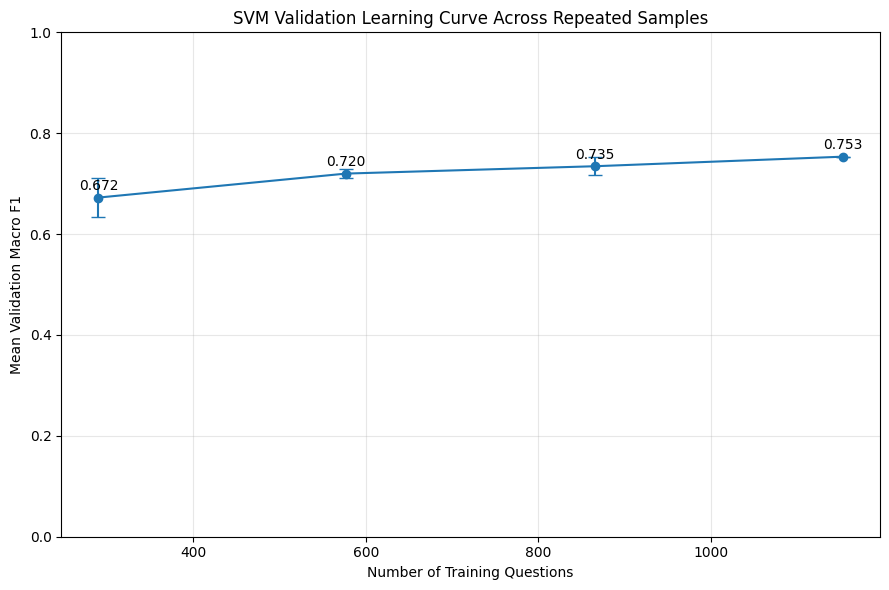

In [ ]:
curve_summary_plot = curve_summary.copy()

curve_summary_plot["Training Fraction Numeric"] = (
    curve_summary_plot["Training Fraction"]
    .str.replace("%", "", regex=False)
    .astype(int)
)

plt.figure(figsize=(9, 6))

plt.errorbar(
    curve_summary_plot["Training Examples"],
    curve_summary_plot["mean"],
    yerr=curve_summary_plot["std"],
    marker="o",
    capsize=5
)

for x, y in zip(
    curve_summary_plot["Training Examples"],
    curve_summary_plot["mean"]
):
    plt.text(
        x,
        y + 0.015,
        f"{y:.3f}",
        ha="center"
    )

plt.title("SVM Validation Learning Curve Across Repeated Samples")
plt.xlabel("Number of Training Questions")
plt.ylabel("Mean Validation Macro F1")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Part 4 — DistilBERT Fine-Tuning

### A pretrained DistilBERT model is fine-tuned for STUDI's four-class cognitive-level classification task.

Unlike the TF-IDF + Linear SVM baseline, DistilBERT represents each question using contextual token representations learned during pretraining.

Before fine-tuning, the token-length distribution of the development data is examined so that the model's maximum sequence length can be selected based on the actual dataset rather than an arbitrary default.

## 4.1 Inspect DistilBERT Token Lengths

### Question lengths are measured using the DistilBERT tokenizer before selecting the maximum input sequence length.

Only the training and validation questions are used for this analysis. The reserved test partition remains excluded from model-development decisions.

The resulting token-length distribution is used to determine whether a sequence length such as 128 tokens captures nearly all questions without unnecessary padding and computation.

In [ ]:
from transformers import AutoTokenizer

distilbert_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    distilbert_checkpoint
)

print("Tokenizer loaded:", distilbert_checkpoint)

Tokenizer loaded: distilbert-base-uncased


In [ ]:
development_questions = pd.concat(
    [
        X_train.reset_index(drop=True),
        X_val.reset_index(drop=True)
    ],
    ignore_index=True
)

print("Development questions:", len(development_questions))

Development questions: 1442


In [ ]:
token_lengths = []

for question in development_questions:
    encoded = tokenizer(
        question,
        add_special_tokens=True,
        truncation=False
    )

    token_lengths.append(
        len(encoded["input_ids"])
    )

token_lengths = np.array(token_lengths)

print("Token-length analysis completed.")

Token-length analysis completed.


In [ ]:
percentiles = [50, 75, 90, 95, 99]

print("Token length statistics")
print("-----------------------")
print("Minimum:", token_lengths.min())
print("Mean:", round(token_lengths.mean(), 2))
print("Median:", int(np.median(token_lengths)))
print("Maximum:", token_lengths.max())

print()

for percentile in percentiles:
    value = np.percentile(
        token_lengths,
        percentile
    )

    print(
        f"{percentile}th percentile:",
        round(value, 2)
    )

Token length statistics
-----------------------
Minimum: 5
Mean: 19.61
Median: 17
Maximum: 84

50th percentile: 17.0
75th percentile: 23.0
90th percentile: 34.0
95th percentile: 40.0
99th percentile: 56.0


### Development-Set Token Length Distribution

The histogram shows the number of DistilBERT tokens required to represent each question in the cleaned development dataset.

The distribution is used together with percentile and coverage statistics to select an efficient maximum sequence length for model fine-tuning.

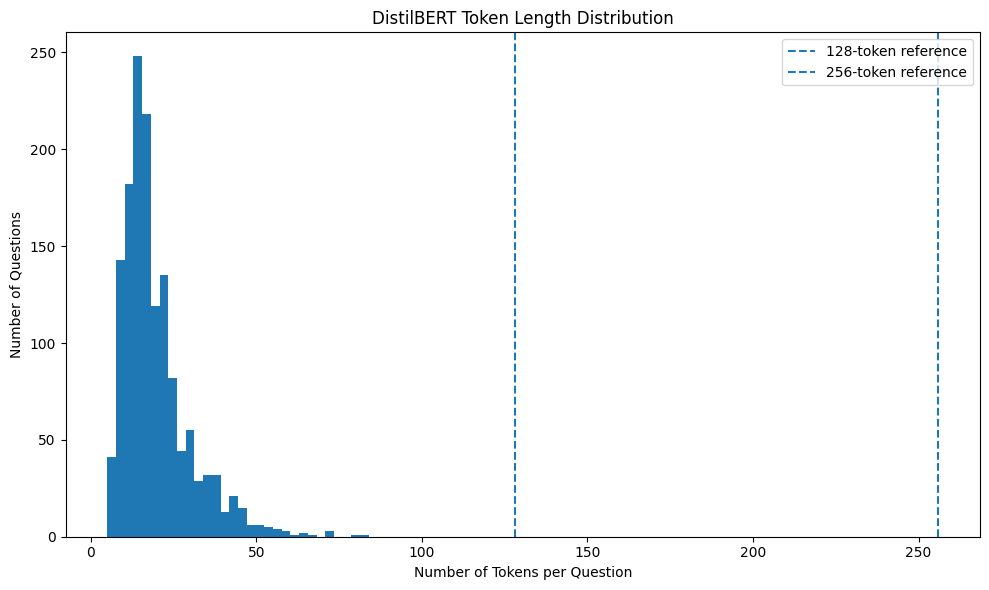

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    token_lengths,
    bins=30
)

plt.axvline(
    128,
    linestyle="--",
    label="128-token reference"
)

plt.axvline(
    256,
    linestyle="--",
    label="256-token reference"
)

plt.title("DistilBERT Token Length Distribution")
plt.xlabel("Number of Tokens per Question")
plt.ylabel("Number of Questions")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
token_length_df = pd.DataFrame({
    "QUESTION": development_questions,
    "TOKEN LENGTH": token_lengths
})

longest_questions = (
    token_length_df
    .sort_values(
        "TOKEN LENGTH",
        ascending=False
    )
    .head(10)
)

display(longest_questions)

,QUESTION,TOKEN LENGTH
1439,Trace the value of alpha after the following c...,84
1205,Microbiota-based models may be an alternative ...,79
546,Sketch a graph that associates with a monopoly...,73
259,Suppose that Japan and South Korea are trading...,71
1217,A banker's acceptance (BA) is a promised futur...,71
795,Trace the contents of matrix from the followin...,67
378,The Malaysian economy is currently operating a...,64
1253,"According to many researchers, market ineffici...",63
1110,Derive the data rate that is generated by the ...,62
309,Hersey and Blanchard (1977) style of leadershi...,60


## 4.2 Prepare DistilBERT Labels and Tokenized Datasets

### The four STUDI cognitive levels are encoded as numerical class labels and the training and validation questions are tokenized for DistilBERT.

A maximum sequence length of 128 tokens is used based on the token-length analysis in Section 4.1. Dynamic padding will later be applied during batching so that shorter questions are not unnecessarily padded to the full maximum length.

Only the training and validation partitions are prepared during model development. The reserved test partition remains excluded.

In [ ]:
label2id = {
    "Remembering": 0,
    "Understanding": 1,
    "Applying": 2,
    "Analyzing": 3
}

id2label = {
    value: key
    for key, value in label2id.items()
}

print("Label mapping:")
print(label2id)

Label mapping:
{'Remembering': 0, 'Understanding': 1, 'Applying': 2, 'Analyzing': 3}


In [ ]:
distilbert_train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True).map(label2id)
})

distilbert_val_df = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "label": y_val.reset_index(drop=True).map(label2id)
})

display(distilbert_train_df.head())
display(distilbert_val_df.head())

,text,label
0,"In all analysis methods, the effects of turbul...",1
1,With respect to the data processing cycle of a...,1
2,Analyze the effect of similarity-dissimilarity...,3
3,List FIVE (5) suggestions on how Malaysian pub...,0
4,Briefly explain any TWO (2) advantages of real...,1


,text,label
0,Explain the FOUR (4) roles of media during a c...,1
1,Calculate the variance of orders for the glass...,2
2,Complete an analogy (analogy tasks are inferen...,1
3,"In your opinion, discuss how modern supply cha...",1
4,How does...compare/contrast with...?,3


In [ ]:
assert distilbert_train_df["label"].notna().all()
assert distilbert_val_df["label"].notna().all()

assert set(distilbert_train_df["label"].unique()) == {0, 1, 2, 3}
assert set(distilbert_val_df["label"].unique()) == {0, 1, 2, 3}

print("DistilBERT label encoding verification passed.")

DistilBERT label encoding verification passed.


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    distilbert_train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    distilbert_val_df,
    preserve_index=False
)

print("Training dataset:", train_dataset)
print("Validation dataset:", val_dataset)

Training dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 1153
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 289
})


In [ ]:
MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_batch,
    batched=True
)

print("Tokenization completed.")

Map:   0%|          | 0/1153 [00:00<?, ? examples/s]

Map:   0%|          | 0/289 [00:00<?, ? examples/s]

Tokenization completed.


In [ ]:
sample = tokenized_train[0]

print("Original question:")
print(sample["text"])

print("\nClass ID:")
print(sample["label"])

print("\nDecoded class:")
print(id2label[sample["label"]])

print("\nToken count:")
print(len(sample["input_ids"]))

print("\nToken IDs:")
print(sample["input_ids"])

Original question:
In all analysis methods, the effects of turbulence have to be modeled unless all the scales of motion are represented explicitly as in Direct Numerical Simulation (DNS). Explain why it is not practical to analyze flows in practical hydraulic engineering by DNS.

Class ID:
1

Decoded class:
Understanding

Token count:
51

Token IDs:
[101, 1999, 2035, 4106, 4725, 1010, 1996, 3896, 1997, 29083, 2031, 2000, 2022, 14440, 4983, 2035, 1996, 9539, 1997, 4367, 2024, 3421, 12045, 2004, 1999, 3622, 15973, 12504, 1006, 1040, 3619, 1007, 1012, 4863, 2339, 2009, 2003, 2025, 6742, 2000, 17908, 6223, 1999, 6742, 14761, 3330, 2011, 1040, 3619, 1012, 102]


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dynamic padding configured.")

Dynamic padding configured.


## 4.3 Configure the Initial DistilBERT Model

### A pretrained DistilBERT sequence-classification model is initialized for the four STUDI cognitive levels.

The model is fine-tuned using the same training and validation partitions used for the SVM experiments. Validation Macro F1 is used as the primary model-selection metric because the dataset is imbalanced across cognitive levels.

The initial configuration uses a standard learning rate, moderate batch size, mixed-precision training on the available GPU, and multiple training epochs so that validation performance can be monitored for improvement or overfitting.

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Training device: cuda
GPU: Tesla T4


In [ ]:
from transformers import AutoModelForSequenceClassification

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    distilbert_checkpoint,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

print("DistilBERT classification model initialized.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT classification model initialized.


In [ ]:
def compute_distilbert_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "macro_precision": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./studi_distilbert",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    seed=SEED,
    data_seed=SEED,

    save_total_limit=2,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=distilbert_model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_distilbert_metrics
)

print("DistilBERT Trainer configured.")

DistilBERT Trainer configured.


In [ ]:
print("DistilBERT training configuration")
print("---------------------------------")
print("Training examples:", len(tokenized_train))
print("Validation examples:", len(tokenized_val))
print("Maximum sequence length:", MAX_LENGTH)
print("Training batch size:", training_args.per_device_train_batch_size)
print("Epochs:", training_args.num_train_epochs)
print("Learning rate:", training_args.learning_rate)
print("Mixed precision:", training_args.fp16)
print("Primary selection metric:", training_args.metric_for_best_model)

DistilBERT training configuration
---------------------------------
Training examples: 1153
Validation examples: 289
Maximum sequence length: 128
Training batch size: 16
Epochs: 5
Learning rate: 2e-05
Mixed precision: True
Primary selection metric: macro_f1


## 4.4 Fine-Tune DistilBERT

### DistilBERT is fine-tuned on the STUDI training subset for up to five epochs.

Performance is evaluated on the validation subset after each epoch. The checkpoint achieving the highest validation Macro F1 is retained as the selected model state for subsequent validation analysis.

In [ ]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.123290,0.879044,0.629758,0.821429,0.455928,0.487721,0.572332
2,0.703034,0.539056,0.799308,0.801075,0.753536,0.771436,0.797363
3,0.428655,0.466858,0.837370,0.826538,0.829664,0.818928,0.837809
4,0.314889,0.446292,0.833910,0.841411,0.809984,0.822584,0.833088
5,0.262228,0.434946,0.851211,0.845445,0.838878,0.839230,0.850500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 4.5 Analyze DistilBERT Training Behavior


### Training and validation performance across epochs are examined to assess model convergence and potential overfitting.

Training loss, validation loss, and validation Macro F1 are tracked across the five fine-tuning epochs. The validation trajectory is used to determine whether the model has begun to overfit or whether additional training may still provide improvement.

In [ ]:
log_history = trainer.state.log_history

epoch_history = []

for entry in log_history:
    if "eval_loss" in entry:
        epoch_history.append({
            "Epoch": entry["epoch"],
            "Validation Loss": entry["eval_loss"],
            "Validation Accuracy": entry["eval_accuracy"],
            "Validation Macro F1": entry["eval_macro_f1"],
            "Validation Macro Precision": entry["eval_macro_precision"],
            "Validation Macro Recall": entry["eval_macro_recall"]
        })

history_df = pd.DataFrame(epoch_history)

display(history_df.round(4))

,Epoch,Validation Loss,Validation Accuracy,Validation Macro F1,Validation Macro Precision,Validation Macro Recall
0,1.0,0.8790,0.6298,0.4877,0.8214,0.4559
1,2.0,0.5391,0.7993,0.7714,0.8011,0.7535
2,3.0,0.4669,0.8374,0.8189,0.8265,0.8297
3,4.0,0.4463,0.8339,0.8226,0.8414,0.8100
4,5.0,0.4349,0.8512,0.8392,0.8454,0.8389


In [ ]:
training_losses = [
    entry
    for entry in log_history
    if "loss" in entry and "eval_loss" not in entry
]

train_loss_df = pd.DataFrame({
    "Epoch": [entry["epoch"] for entry in training_losses],
    "Training Loss": [entry["loss"] for entry in training_losses]
})

display(train_loss_df.round(4))

,Epoch,Training Loss
0,1.0,1.1233
1,2.0,0.7030
2,3.0,0.4287
3,4.0,0.3149
4,5.0,0.2622


### Training and Validation Loss Across Epochs

Loss values are compared across epochs to determine whether the model continues to improve on unseen validation data as training progresses.

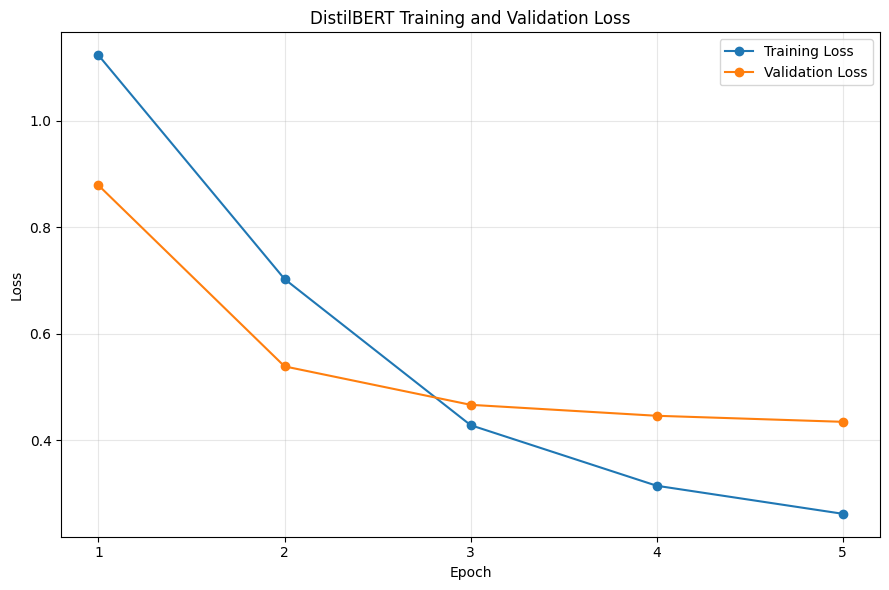

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    train_loss_df["Epoch"],
    train_loss_df["Training Loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["Validation Loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("DistilBERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(history_df["Epoch"])
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Validation Macro F1 Across Epochs

Validation Macro F1 is tracked across fine-tuning epochs because it is the primary model-selection metric for the imbalanced four-class classification task.

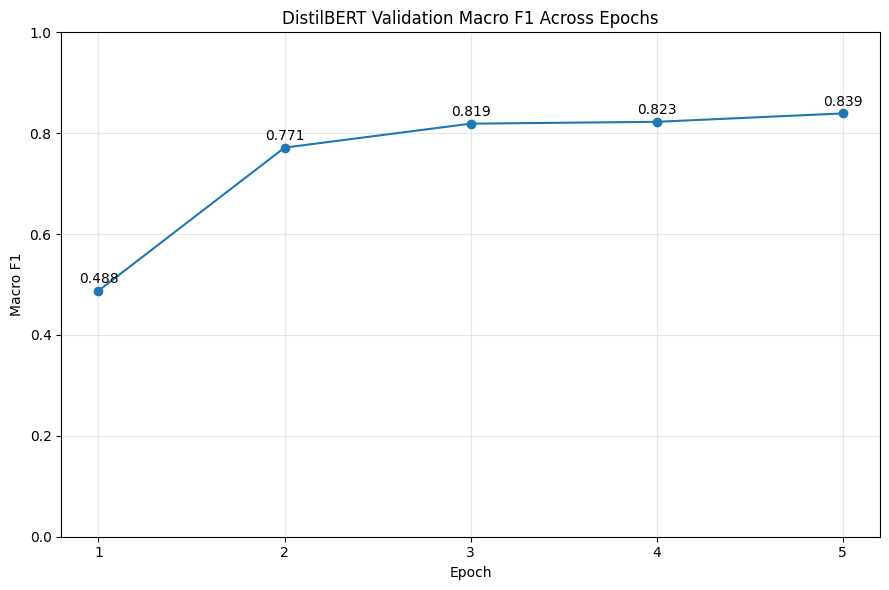

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    history_df["Epoch"],
    history_df["Validation Macro F1"],
    marker="o"
)

for x, y in zip(
    history_df["Epoch"],
    history_df["Validation Macro F1"]
):
    plt.text(
        x,
        y + 0.015,
        f"{y:.3f}",
        ha="center"
    )

plt.title("DistilBERT Validation Macro F1 Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(history_df["Epoch"])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Initial DistilBERT Training Interpretation

Validation Macro F1 increased substantially across fine-tuning, from 0.4877 after the first epoch to 0.8392 after the fifth epoch. Validation loss also decreased continuously from 0.8790 to 0.4349.

No clear evidence of overfitting was observed within the five-epoch training window because validation loss continued to decline while Macro F1 reached its highest value at the final epoch.

Because the best validation performance occurred at the maximum configured epoch rather than at an earlier checkpoint, the five-epoch limit does not provide evidence that the model has fully converged. Additional controlled training is therefore warranted before finalizing the DistilBERT epoch configuration.

## 4.6 Determine an Appropriate Fine-Tuning Duration

### The DistilBERT fine-tuning duration is extended to examine whether validation performance continues to improve beyond five epochs.

The initial five-epoch experiment achieved its highest validation Macro F1-score at the final configured epoch while validation loss was still decreasing. This provides insufficient evidence that the model had reached its optimal training duration.

A fresh DistilBERT model is therefore fine-tuned for eight epochs using the same training data, validation data, random seed, learning rate, batch size, and other training settings. Only the maximum number of epochs is changed so that the effect of additional training can be evaluated directly.

In [ ]:
from transformers import set_seed

set_seed(SEED)

distilbert_model_8epoch = AutoModelForSequenceClassification.from_pretrained(
    distilbert_checkpoint,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

print("Fresh DistilBERT model initialized for the 8-epoch experiment.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh DistilBERT model initialized for the 8-epoch experiment.


In [ ]:
training_args_8epoch = TrainingArguments(
    output_dir="./studi_distilbert_8epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=8,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    seed=SEED,
    data_seed=SEED,

    save_total_limit=2,

    report_to="none"
)

In [ ]:
trainer_8epoch = Trainer(
    model=distilbert_model_8epoch,
    args=training_args_8epoch,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_distilbert_metrics
)

print("8-epoch DistilBERT Trainer configured.")

8-epoch DistilBERT Trainer configured.


In [ ]:
print("Extended DistilBERT training configuration")
print("-----------------------------------------")
print("Training examples:", len(tokenized_train))
print("Validation examples:", len(tokenized_val))
print("Maximum sequence length:", MAX_LENGTH)
print("Training batch size:", training_args_8epoch.per_device_train_batch_size)
print("Epochs:", training_args_8epoch.num_train_epochs)
print("Learning rate:", training_args_8epoch.learning_rate)
print("Mixed precision:", training_args_8epoch.fp16)
print("Primary selection metric:", training_args_8epoch.metric_for_best_model)

Extended DistilBERT training configuration
-----------------------------------------
Training examples: 1153
Validation examples: 289
Maximum sequence length: 128
Training batch size: 16
Epochs: 8
Learning rate: 2e-05
Mixed precision: True
Primary selection metric: macro_f1


### Extended Fine-Tuning Run

The fresh DistilBERT model is trained for eight epochs while validation performance is measured after every epoch. The checkpoint with the highest validation Macro F1-score is automatically restored after training.

In [ ]:
train_result_8epoch = trainer_8epoch.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.119244,0.867478,0.636678,0.823195,0.466291,0.502755,0.583491
2,0.678318,0.510609,0.820069,0.814602,0.789361,0.796375,0.819150
3,0.386262,0.446742,0.851211,0.844618,0.851887,0.842007,0.851884
4,0.259376,0.449943,0.833910,0.847589,0.803045,0.820943,0.832452
5,0.182995,0.453920,0.833910,0.819373,0.818136,0.818584,0.833871
6,0.129740,0.471605,0.840830,0.838151,0.822936,0.830027,0.840626
7,0.094587,0.511434,0.840830,0.842619,0.819214,0.830227,0.840280
8,0.077645,0.508137,0.840830,0.837307,0.822936,0.829773,0.840498


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Extended DistilBERT Training Trajectory

The extended training trajectory illustrates the relationship between continued optimization of the training data and generalization to the validation set. The best validation Macro F1 and lowest validation loss occur at approximately the third epoch, after which validation performance no longer improves.

In [ ]:
log_history_8 = trainer_8epoch.state.log_history

eval_history_8 = []

for entry in log_history_8:
    if "eval_loss" in entry:
        eval_history_8.append({
            "Epoch": entry["epoch"],
            "Validation Loss": entry["eval_loss"],
            "Validation Accuracy": entry["eval_accuracy"],
            "Validation Macro F1": entry["eval_macro_f1"]
        })

eval_history_8_df = pd.DataFrame(eval_history_8)

training_history_8 = [
    entry
    for entry in log_history_8
    if "loss" in entry and "eval_loss" not in entry
]

train_history_8_df = pd.DataFrame({
    "Epoch": [entry["epoch"] for entry in training_history_8],
    "Training Loss": [entry["loss"] for entry in training_history_8]
})

display(eval_history_8_df.round(4))

,Epoch,Validation Loss,Validation Accuracy,Validation Macro F1
0,1.0,0.8675,0.6367,0.5028
1,2.0,0.5106,0.8201,0.7964
2,3.0,0.4467,0.8512,0.8420
3,4.0,0.4499,0.8339,0.8209
4,5.0,0.4539,0.8339,0.8186
5,6.0,0.4716,0.8408,0.8300
6,7.0,0.5114,0.8408,0.8302
7,8.0,0.5081,0.8408,0.8298


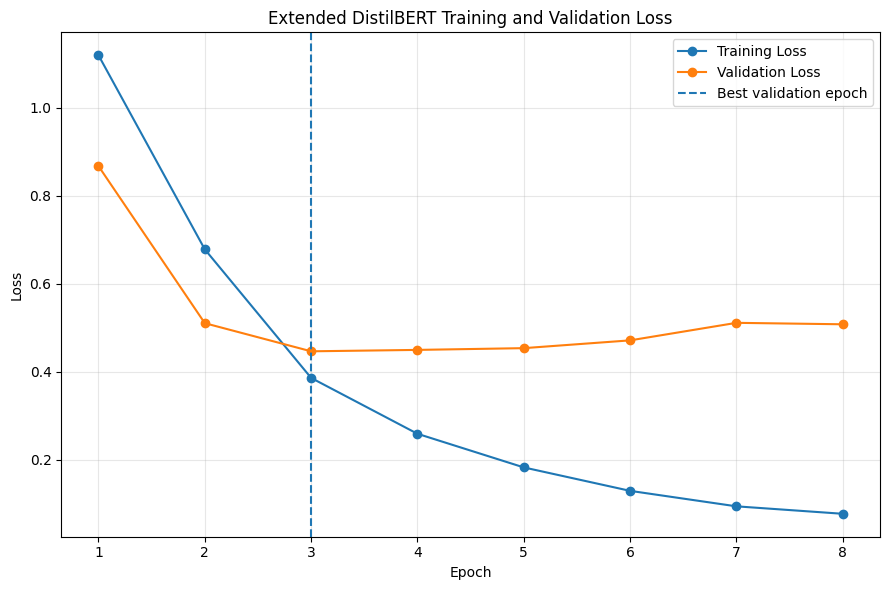

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    train_history_8_df["Epoch"],
    train_history_8_df["Training Loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    eval_history_8_df["Epoch"],
    eval_history_8_df["Validation Loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    3,
    linestyle="--",
    label="Best validation epoch"
)

plt.title("Extended DistilBERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, 9))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

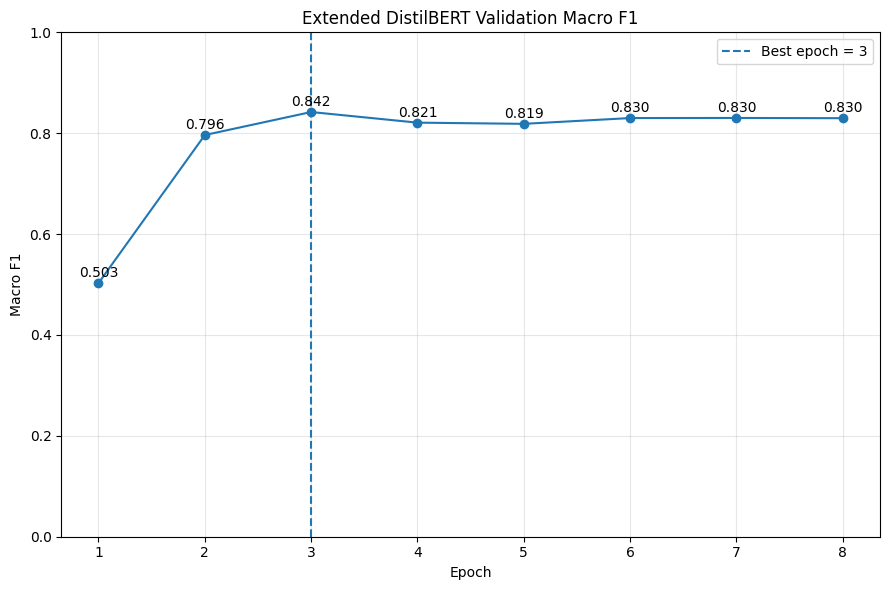

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    eval_history_8_df["Epoch"],
    eval_history_8_df["Validation Macro F1"],
    marker="o"
)

best_epoch_index = (
    eval_history_8_df["Validation Macro F1"].idxmax()
)

best_epoch = int(
    eval_history_8_df.loc[best_epoch_index, "Epoch"]
)

best_macro_f1 = (
    eval_history_8_df.loc[
        best_epoch_index,
        "Validation Macro F1"
    ]
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

for x, y in zip(
    eval_history_8_df["Epoch"],
    eval_history_8_df["Validation Macro F1"]
):
    plt.text(
        x,
        y + 0.012,
        f"{y:.3f}",
        ha="center"
    )

plt.title("Extended DistilBERT Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(range(1, 9))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Best checkpoint:", trainer_8epoch.state.best_model_checkpoint)
print("Best validation Macro F1:", trainer_8epoch.state.best_metric)

Best checkpoint: ./studi_distilbert_8epoch/checkpoint-219
Best validation Macro F1: 0.8420068709938301


## 4.7 Evaluate DistilBERT Stability Across Random Seeds

### DistilBERT is fine-tuned repeatedly using different random seeds to evaluate the stability of its validation performance.

Each run uses the same training and validation data, tokenizer, maximum sequence length, learning rate, batch size, weight decay, and three-epoch training limit.

Only the random seed is changed. A fresh model is initialized for every run so that variation in validation performance reflects sensitivity to random initialization and training randomness.

The reserved test partition remains unused during this experiment.

In [ ]:
from transformers import set_seed

distilbert_seeds = [42, 123, 2026]

seed_results = []
seed_histories = {}

for seed in distilbert_seeds:
    print(f"\n{'=' * 50}")
    print(f"Starting DistilBERT run with seed {seed}")
    print(f"{'=' * 50}")

    # Reset all relevant random states before model initialization.
    set_seed(seed)

    model_seed = AutoModelForSequenceClassification.from_pretrained(
        distilbert_checkpoint,
        num_labels=4,
        id2label=id2label,
        label2id=label2id
    )

    args_seed = TrainingArguments(
        output_dir=f"./studi_distilbert_seed_{seed}",

        learning_rate=2e-5,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=3,

        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",

        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        fp16=torch.cuda.is_available(),

        seed=seed,
        data_seed=seed,

        save_total_limit=1,

        report_to="none"
    )

    trainer_seed = Trainer(
        model=model_seed,
        args=args_seed,

        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,

        processing_class=tokenizer,
        data_collator=data_collator,

        compute_metrics=compute_distilbert_metrics
    )

    trainer_seed.train()

    # Evaluate the best checkpoint restored by Trainer.
    eval_result = trainer_seed.evaluate()

    # Extract epoch-level validation history.
    epoch_logs = [
        entry
        for entry in trainer_seed.state.log_history
        if "eval_macro_f1" in entry
    ]

    seed_histories[seed] = epoch_logs

    best_log = max(
        epoch_logs,
        key=lambda entry: entry["eval_macro_f1"]
    )

    seed_results.append({
        "Seed": seed,
        "Best Epoch": best_log["epoch"],
        "Accuracy": eval_result["eval_accuracy"],
        "Macro Precision": eval_result["eval_macro_precision"],
        "Macro Recall": eval_result["eval_macro_recall"],
        "Macro F1": eval_result["eval_macro_f1"],
        "Weighted F1": eval_result["eval_weighted_f1"]
    })

print("\nRandom-seed experiment completed.")


Starting DistilBERT run with seed 42


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,1.131292,0.903405,0.602076,0.799682,0.412835,0.430886,0.530902
2,0.755163,0.605217,0.775087,0.769119,0.729128,0.745167,0.772371
3,0.547950,0.546434,0.806228,0.798482,0.777414,0.782367,0.805047


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0.551578,0.561948,3,0.809689,0.806501,0.776152,0.785123,0.809495



Random-seed experiment completed.


In [ ]:
seed_results_df = pd.DataFrame(seed_results)

display(
    seed_results_df.round(4)
)

,Seed,Best Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,42,3.0,0.8062,0.7985,0.7774,0.7824,0.8050
1,123,3.0,0.8131,0.8169,0.7699,0.7882,0.8117
2,2026,3.0,0.8097,0.8065,0.7762,0.7851,0.8095


In [ ]:
seed_summary = pd.DataFrame({
    "Mean": seed_results_df[
        [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1"
        ]
    ].mean(),

    "Standard Deviation": seed_results_df[
        [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1"
        ]
    ].std(ddof=1)
})

display(seed_summary.round(4))

,Mean,Standard Deviation
Accuracy,0.8097,0.0035
Macro Precision,0.8073,0.0092
Macro Recall,0.7745,0.0040
Macro F1,0.7852,0.0029
Weighted F1,0.8087,0.0034


### Validation Macro F1 Across Random Seeds

Validation Macro F1 is compared across repeated DistilBERT fine-tuning runs to assess whether model performance is stable under different random initializations.

Small variation across seeds would indicate that the observed validation performance is reproducible rather than dependent on a single favorable run.

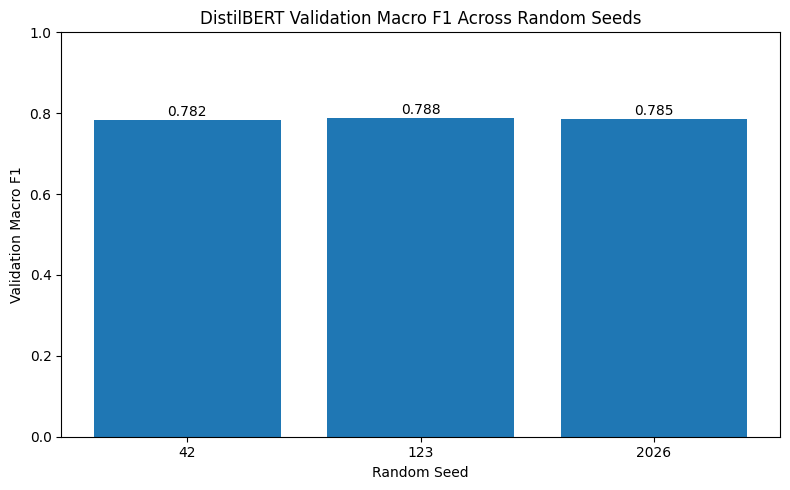

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    seed_results_df["Seed"].astype(str),
    seed_results_df["Macro F1"]
)

for x, y in zip(
    seed_results_df["Seed"].astype(str),
    seed_results_df["Macro F1"]
):
    plt.text(
        x,
        y + 0.01,
        f"{y:.3f}",
        ha="center"
    )

plt.title("DistilBERT Validation Macro F1 Across Random Seeds")
plt.xlabel("Random Seed")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
display(
    seed_results_df[
        ["Seed", "Best Epoch", "Macro F1"]
    ].round(4)
)

,Seed,Best Epoch,Macro F1
0,42,3.0,0.7824
1,123,3.0,0.7882
2,2026,3.0,0.7851


**Checkpoint — September 21, 2026**

In [ ]:
import os
import json

checkpoint_dir = "/content/drive/MyDrive/STUDI_Checkpoints/2026-09-21"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save prepared DistilBERT development data
distilbert_train_df.to_csv(
    f"{checkpoint_dir}/distilbert_train.csv",
    index=False
)

distilbert_val_df.to_csv(
    f"{checkpoint_dir}/distilbert_validation.csv",
    index=False
)

# Save the configuration needed to reconstruct the experiment
checkpoint_config = {
    "model_checkpoint": distilbert_checkpoint,
    "max_length": MAX_LENGTH,
    "label2id": label2id,
    "id2label": {str(k): v for k, v in id2label.items()},
    "learning_rate": 2e-5,
    "train_batch_size": 16,
    "eval_batch_size": 16,
    "weight_decay": 0.01,
    "extended_epochs": 8,
    "seed": SEED
}

with open(
    f"{checkpoint_dir}/config.json",
    "w"
) as f:
    json.dump(checkpoint_config, f, indent=2)

# Save completed experiment results
eval_history_8_df.to_csv(
    f"{checkpoint_dir}/eight_epoch_history.csv",
    index=False
)

seed_results_df.to_csv(
    f"{checkpoint_dir}/three_epoch_seed_results.csv",
    index=False
)

seed_summary.to_csv(
    f"{checkpoint_dir}/three_epoch_seed_summary.csv"
)

# Save the best model currently loaded from the 8-epoch seed-42 run
best_model_dir = f"{checkpoint_dir}/best_seed42_model"

trainer_8epoch.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

print("Checkpoint saved successfully.")
print("Location:", checkpoint_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint saved successfully.
Location: /content/drive/MyDrive/STUDI_Checkpoints/2026-09-21
